<a href="https://colab.research.google.com/github/calebriggs1120/Data-Mining-Project-26/blob/main/DataMining_Project_Caleb_Schell_Spring_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Caleb Schell
## 4/17/2026
## Analyzing Student Drop Out Factors and Classification Modeling

## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**

## GitHub + Colab workflow
1. Create a **new GitHub repository** for your project.
2. Upload this notebook to your repository.
3. In GitHub, open the notebook in **Google Colab**.
4. Commit changes to GitHub as you work.
5. Submit your GitHub repository link when requested.

## Project requirements
- Use a **classification dataset**
- Use **Random Forest** as one of your main models
- Use **Google Colab**
- Include **visualization, preparation, modeling, and interpretation**
- Explain results in a way a manager or stakeholder could understand


In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz
!pip install autoviz -q
from autoviz.AutoViz_Class import AutoViz_Class

# scikit-learn tools (Colab-friendly replacement for PyCaret)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, cohen_kappa_score

# Models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


# Deliverable 1: Problem Framing & Data Acquisition

## What to include in this markdown cell

- This model is meant to help identify key indicators of drop out rates in colleges and universities.
- The target variable is whether a student graduated or dropped out.
- This model is intended to be used by higher educational institutions.
- Identifying key features that contribute to drop out rates can help focus an institution's efforts on improving specific areas to retain students.
- The dataset was obtained from the UCI online database.
- As someone who works in high education admissions, I found this dataset to be interesting as a possibility to gain insights into factors contributing to student retention rates.


## Data loading options

Choose **one** of the options below:
- load a CSV from GitHub
- upload a CSV into Colab
- read from a direct URL

Keep your original raw data file in your GitHub repository whenever possible.


In [ ]:
# Option A: Load from a direct CSV URL
# Example:
# data_url = "https://raw.githubusercontent.com/yourusername/yourrepo/main/data/yourfile.csv"
# df = pd.read_csv(data_url)


# Replace this with your own dataset path or URL
data_path = "/content/drive/MyDrive/data.csv Updated.csv"
df = pd.read_csv(data_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# Deliverable 2: Exploratory Data Analysis (EDA) & Data Preparation

## What to include
- basic shape and structure of the data
- variable types
- missing values
- class balance of the target
- visualizations that help explain the data
- preparation steps you used before modeling

## Suggested questions to resolve
- Are there missing values?
- Are the classes balanced?
- Which variables might be useful predictors?
- Are any variables likely to cause problems?
- Do I need to eliminate any variables due to correlation, redundancy, or uniqueness (ex. id)?


In [ ]:
# Basic data inspection
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)


Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance\t,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


In [ ]:
display(df["Marital status"].unique())

array([1, 2, 4, 3, 5, 6])

In [ ]:
display(df["Course"].unique())

array([ 171, 9254, 9070, 9773, 8014, 9991, 9500, 9238, 9670, 9853, 9085,
       9130, 9556, 9147, 9003,   33, 9119])

In [ ]:
display(df["Target"].unique())

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [ ]:
df['Target'].value_counts()['Enrolled']

np.int64(794)

In [ ]:
# Missing values summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
display(missing_summary)


,0


In [ ]:
# TODO: Replace with your actual target column name
target = "Target"

# Class balance
display(df[target].value_counts(dropna=False))
display(df[target].value_counts(normalize=True, dropna=False))


,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


,proportion
Target,
Graduate,0.499322
Dropout,0.321203
Enrolled,0.179476


While no missing values exist, a few columns and rows should be dropped due to lack of significance to an ML model. Column "Marriage status" is heavily skewed by one value (vast majority of students are single), "Nacionality" has 109 unique values and is therefore not helpful, and rows that contain a target value of "Enrolled" are not useful in supervised learning models; these will all be dropped.

In [ ]:
df = df[df['Target'] != 'Enrolled']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3630 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3630 non-null   int64  
 1   Application mode                                3630 non-null   int64  
 2   Application order                               3630 non-null   int64  
 3   Course                                          3630 non-null   int64  
 4   Daytime/evening attendance	                     3630 non-null   int64  
 5   Previous qualification                          3630 non-null   int64  
 6   Previous qualification (grade)                  3630 non-null   float64
 7   Nacionality                                     3630 non-null   int64  
 8   Mother's qualification                          3630 non-null   int64  
 9   Father's qualification                        

In [ ]:
df = df.drop(columns=['Nacionality'])

In [ ]:
df = df.drop(columns=['Marital status'])

In [ ]:
df.head()

,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,17,5,171,1,1,122.0,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,15,1,9254,1,1,160.0,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,5,9070,1,1,122.0,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,17,2,9773,1,1,122.0,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,39,1,8014,0,1,100.0,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


                       Feature                      Importance
28             Curricular units 2nd sem (approved)   0.212561 
22             Curricular units 1st sem (approved)   0.125625 
29                Curricular units 2nd sem (grade)   0.120404 
23                Curricular units 1st sem (grade)   0.075193 
14                         Tuition fees up to date   0.052372 
17                               Age at enrollment   0.036102 
27          Curricular units 2nd sem (evaluations)   0.033531 
10                                 Admission grade   0.027596 
21          Curricular units 1st sem (evaluations)   0.025455 
2                                           Course   0.025366 
5                   Previous qualification (grade)   0.024772 
26             Curricular units 2nd sem (enrolled)   0.019565 
16                              Scholarship holder   0.019397 
20             Curricular units 1st sem (enrolled)   0.019375 
13                                          Debtor   0.

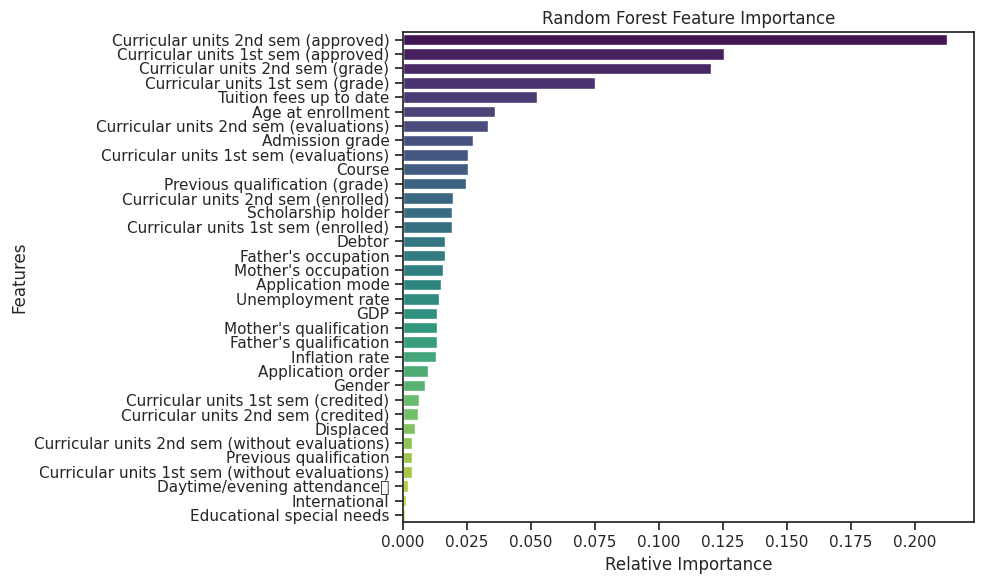

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier # Use RandomForestRegressor for continuous targets

# 1. Separate your features (X) and your target variable (y)
# Replace 'target' with the actual name of the column you are predicting
X = df.drop('Target', axis=1)
y = df['Target']

# 2. Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# 3. Extract the feature importances
importances = model.feature_importances_

# 4. Create a new DataFrame to neatly view the results
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print the text results
print(importance_df)

# 5. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [23]:
columns_to_drop = importance_df[importance_df['Importance'] < 0.01]['Feature'].tolist()

# 2. Drop those columns from your original DataFrame
df_reduced = df.drop(columns=columns_to_drop)

# Optional: Print the results to verify what was removed
print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
print(f"Original shape: {df.shape} | New shape: {df_reduced.shape}")

Dropped 11 columns: ['Application order', 'Gender', 'Curricular units 1st sem (credited)', 'Curricular units 2nd sem (credited)', 'Displaced', 'Curricular units 2nd sem (without evaluations)', 'Previous qualification', 'Curricular units 1st sem (without evaluations)', 'Daytime/evening attendance\t', 'International', 'Educational special needs']
Original shape: (3630, 35) | New shape: (3630, 24)


                   Feature                  Importance
18     Curricular units 2nd sem (approved)   0.222884 
19        Curricular units 2nd sem (grade)   0.128282 
14     Curricular units 1st sem (approved)   0.123257 
15        Curricular units 1st sem (grade)   0.078568 
9                  Tuition fees up to date   0.066632 
11                       Age at enrollment   0.032063 
7                          Admission grade   0.030626 
17  Curricular units 2nd sem (evaluations)   0.030580 
13  Curricular units 1st sem (evaluations)   0.030084 
1                                   Course   0.029313 
2           Previous qualification (grade)   0.028937 
16     Curricular units 2nd sem (enrolled)   0.021907 
10                      Scholarship holder   0.019454 
12     Curricular units 1st sem (enrolled)   0.018295 
6                      Father's occupation   0.018058 
0                         Application mode   0.017345 
5                      Mother's occupation   0.016210 
22        

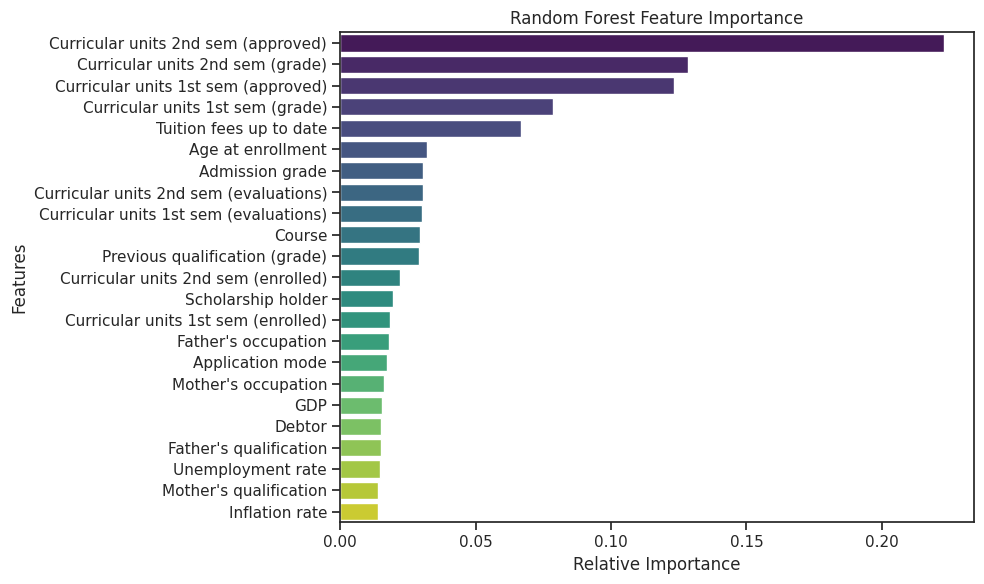

In [25]:
X = df_reduced.drop('Target', axis=1)
y = df_reduced['Target']

# 2. Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# 3. Extract the feature importances
importances = model.feature_importances_

# 4. Create a new DataFrame to neatly view the results
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print the text results
print(importance_df)

# 5. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Determining Feature Importance

## AutoViz integration

AutoViz is useful for fast exploratory analysis. It can generate many plots at once.

**Important for Colab:** after AutoViz runs, use `plt.close('all')` before creating your own plots later in the notebook. This helps prevent old figures from appearing unexpectedly.


In [ ]:
# Install and run AutoViz in Colab if needed
# You may comment this out if AutoViz is already installed in your runtime
%matplotlib inline
!pip install autoviz

from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()


In [ ]:
# AutoViz example
# Replace target with your real target column name before running
# dfte = AV.AutoViz(
#     "",
#     sep=",",
#     depVar=target,
#     dfte=df,
#     header=0,
#     verbose=1,
#     lowess=False,
#     chart_format="svg",
#     max_rows_analyzed=150000,
#     max_cols_analyzed=30
# )

# Clear any queued figures after AutoViz so later plots behave normally in Colab
import matplotlib.pyplot as plt
plt.close('all')


In [ ]:
# Code for custom visualiations (optional)

# Example 1: target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target)
plt.title("Target Distribution")
plt.xticks(rotation=45)
plt.show()

# Example 2: numeric histogram for one variable
# Replace 'REPLACE_NUMERIC_COLUMN' with a numeric column from your dataset
# plt.figure(figsize=(6,4))
# sns.histplot(data=df, x='REPLACE_NUMERIC_COLUMN', kde=True)
# plt.title("Distribution of REPLACE_NUMERIC_COLUMN")
# plt.show()

# Example 3: relationship to target
# Replace with columns from your dataset
# plt.figure(figsize=(7,4))
# sns.boxplot(data=df, x=target, y='REPLACE_NUMERIC_COLUMN')
# plt.title("REPLACE_NUMERIC_COLUMN by Target")
# plt.show()


## Data preparation plan

Explain your preparation steps in plain language:
- columns dropped
- missing value handling
- encoding categorical variables
- train/test split strategy
- any feature engineering

Write a short summary in the markdown cell below this one.


### Student preparation summary
Replace this text with your explanation of how you prepared the data.


# Deliverable 3: Model Development, Evaluation & Interpretation

## What to include
- preprocessing pipeline
- Random Forest model
- parameter tuning
- evaluation on the test set
- confusion matrix
- kappa
- feature importance
- interpretation of what the results mean

## Reminder
You should explain results in a business-friendly way, not only with technical language.


In [ ]:
# Modeling imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score
)


In [ ]:
# Identify feature columns
X = df.drop(columns=[target])
y = df[target]

# If needed, convert target labels here
# Example:
# y = y.map({"No": 0, "Yes": 1})

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


In [ ]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)


In [ ]:
# Baseline Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Cohen's Kappa:", round(cohen_kappa_score(y_test, y_pred), 4))


In [ ]:
# Confusion matrix
import matplotlib.pyplot as plt

plt.close('all')
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Random Forest Confusion Matrix")
plt.show()


## Hyperparameter tuning

We do not know the best settings ahead of time, so we try multiple combinations.

A parameter grid gives the model several choices for each setting. GridSearchCV tests combinations and selects the version that performs best according to the scoring metric.


In [ ]:
# Tune the Random Forest model
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


In [ ]:
# Final evaluation on the test set
best_preds = best_rf.predict(X_test)

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, best_preds))

kappa = cohen_kappa_score(y_test, best_preds)
print("Cohen's Kappa:", round(kappa, 4))


In [ ]:
# Tuned confusion matrix
plt.close('all')
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Tuned Random Forest Confusion Matrix")
plt.show()


## Feature importance

Feature importance helps us see which inputs influenced the Random Forest most.

Be careful:
- importance does **not** prove causation
- importance can be split across multiple one-hot encoded columns
- importance tells us what mattered to the model, not necessarily what matters in the real world


In [ ]:
# Feature importance from the tuned model
import pandas as pd

feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(15))


In [ ]:
# Plot top feature importances
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Interpretation prompts

Write short answers below:
- How well did the model perform?
- Which class was easier or harder to predict?
- Which variables seemed most important?
- Where did the model make mistakes?
- How could this model be used by a real organization?
- What would you improve next?


### Student interpretation summary
Replace this section with your final written interpretation.


# Optional: Save your final processed data file and model

You may save your trained model if you want to show a deployment-style step.


In [ ]:
import joblib

# Example:
# joblib.dump(best_rf, "final_model.pkl")
# print("Model saved.")

# saving data file
from google.colab import drive
drive.mount('/content/drive')

# Save to Drive
df_clean.to_csv('/content/drive/MyDrive/cleaned_data.csv', index=False)